# 本周作业：数据理解与预处理实践

本次作业的目标是让学生掌握 **数据理解** 和 **数据预处理** 相关的基本概念、统计描述、可视化方法以及使用 `sklearn` 进行数据预处理。


## **任务 1：属性及其类型（理论题）**

问题：  
1.解释 标称属性（Nominal）、序数属性（Ordinal）、间隔属性（Interval）、比率属性（Ratio） 的区别，并举例说明。  
2.下列数据属于哪种属性类型？（标称、序数、间隔、比率）  
    (a) 学生考试成绩（A, B, C, D） ‘序数’ 
    (b) 温度（°C）  ‘间隔’
    (c) 人的身高（cm）  ‘比率’
    (d) 邮政编码  ‘标称’
    (e) 电影评分（1星到5星）  ‘序数’

## **任务 2：数据的基本统计描述**

编写代码完成以下任务：  
1.加载鸢尾花数据集（Iris Dataset） 并创建 Pandas DataFrame。  
2.使用 describe() 输出 均值（Mean）、中位数（Median）、众数（Mode）、标准差（Std）、方差（Variance）、最大/最小值（Max/Min）。  
3.分别使用 Pandas 方法 单独计算并输出：  
    均值（df.mean()）
    中位数（df.median()）
    众数（df.mode()）
    标准差（df.std()）
    方差（df.var()）
    最大值/最小值（df.max() / df.min()）

In [16]:
# 任务 2: 数据的基本统计描述

# 步骤 1: 加载鸢尾花数据集并创建 Pandas DataFrame

# 导入必要的库
import pandas as pd
import seaborn as sns

# 使用 seaborn 库加载 Iris 数据集
iris = sns.load_dataset('iris')

# 步骤 2: 使用 describe() 输出统计信息

# 使用 describe() 方法获取描述性统计信息
description = iris.describe()
print("使用 describe() 方法输出的描述性统计信息:\n")
print(description)

# 从 describe() 结果中提取需要的统计量
print("\n从 describe() 结果中提取的统计量:")
print("均值 (Mean):\n", description.loc['mean', :]) # .loc['行标签', '列标签'] 用于按标签索引数据
print("中位数 (Median/50%): \n", description.loc['50%', :]) # describe() 中位数在 50% 行
print("标准差 (Std):\n", description.loc['std', :])
print("最小值 (Min):\n", description.loc['min', :])
print("最大值 (Max):\n", description.loc['max', :])


# 注意: describe() 方法本身不直接输出 众数 (Mode) 和 方差 (Variance).
#      但它输出了中位数 (Median, 对应 50% 百分位数), 我们提取了中位数.
#      众数和方差需要单独计算.


# 步骤 3: 分别使用 Pandas 方法单独计算并输出统计信息

print("\n\n使用 Pandas 方法单独计算并输出的统计信息:")

print("\n均值 (Mean):")
print(iris.mean(numeric_only=True)) # numeric_only=True  仅计算数值列的均值，忽略 'species' 列

print("\n中位数 (Median):")
print(iris.median(numeric_only=True))

print("\n众数 (Mode):")
print(iris.mode()) # 众数可能不止一个，mode() 会返回包含所有众数的 DataFrame

print("\n标准差 (Std):")
print(iris.std(numeric_only=True))

print("\n方差 (Variance):")
print(iris.var(numeric_only=True))

print("\n最大值 (Max):")
print(iris.max(numeric_only=True))

print("\n最小值 (Min):")
print(iris.min(numeric_only=True))

使用 describe() 方法输出的描述性统计信息:

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

从 describe() 结果中提取的统计量:
均值 (Mean):
 sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
Name: mean, dtype: float64
中位数 (Median/50%): 
 sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
Name: 50%, dtype: float64
标准差 (Std):
 sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
Name: std, dtype: float64

## 任务 3：数据可视化

编写代码完成以下任务：  
1.使用 直方图（Histogram） 显示每个特征的分布情况。  
2.使用 箱线图（Boxplot） 检测鸢尾花数据的异常值。  
3.使用 散点图（Scatter Plot） 观察 petal length (cm) 与 petal width (cm) 之间的关系。  

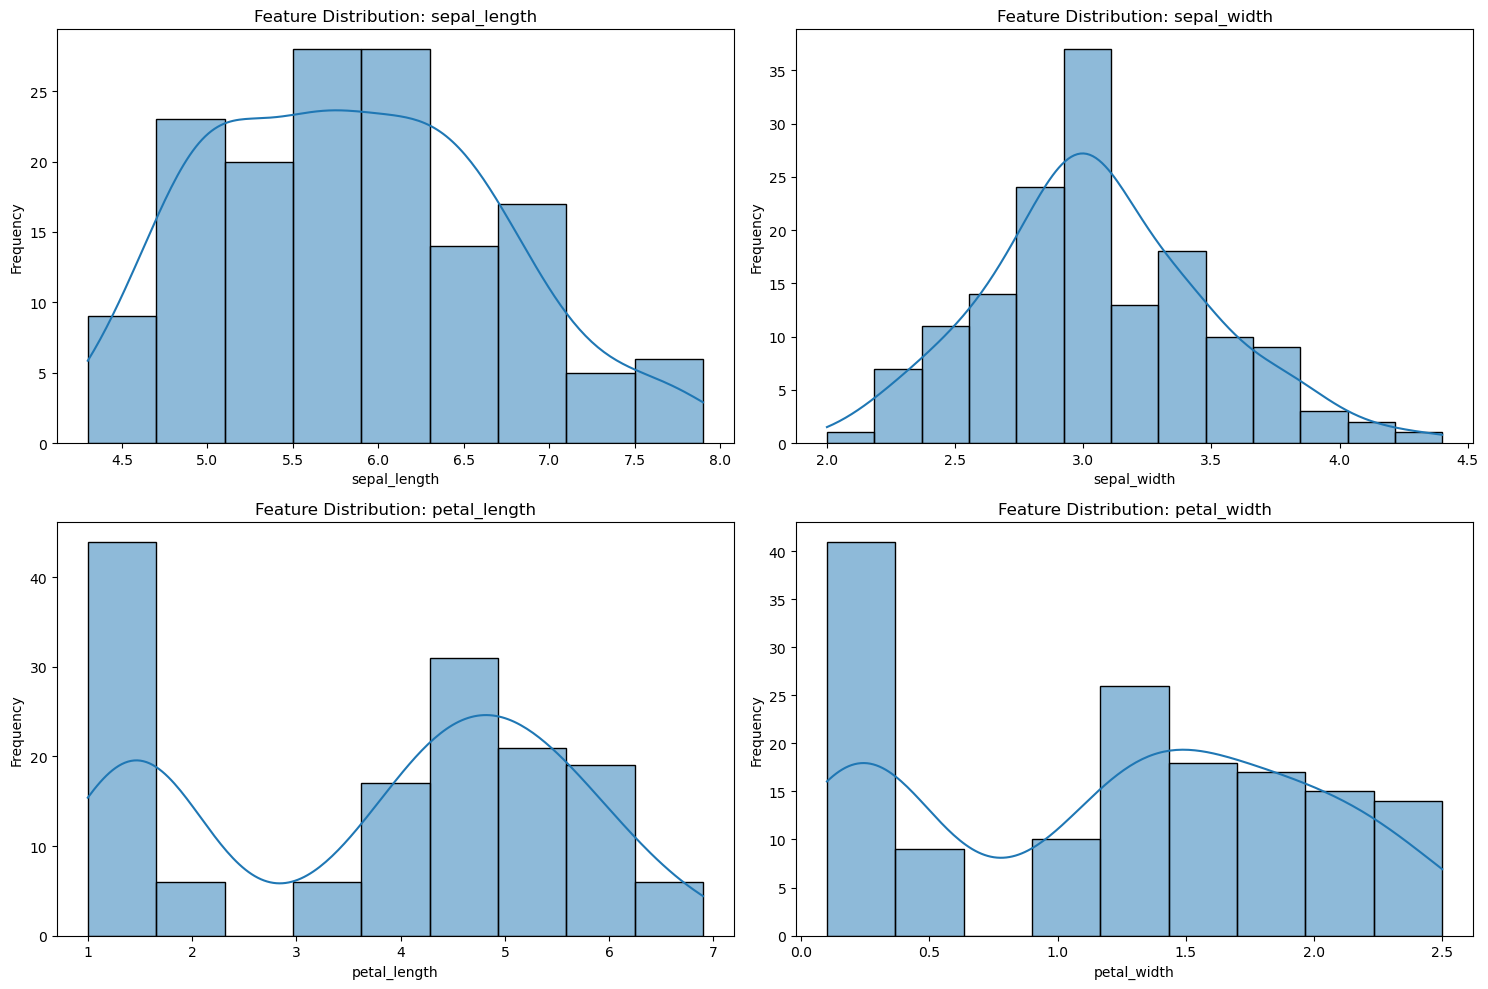


步骤 2: 使用箱线图 (Boxplot) 检测鸢尾花数据的异常值


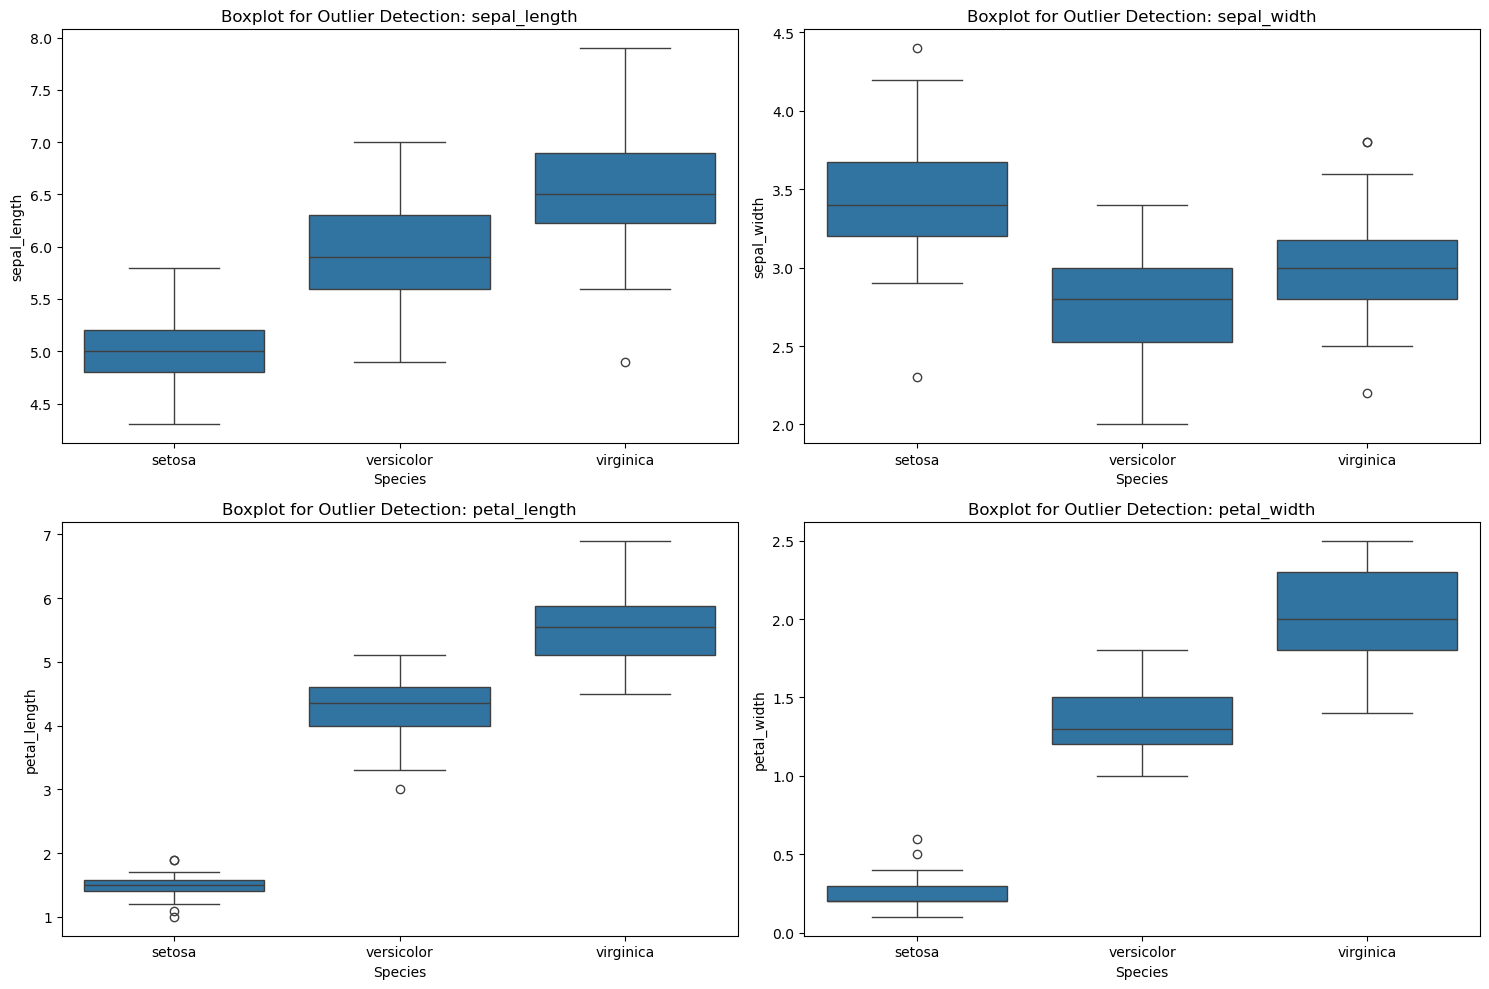


步骤 3: 使用散点图 (Scatter Plot) 观察 petal length (cm) 与 petal width (cm) 之间的关系


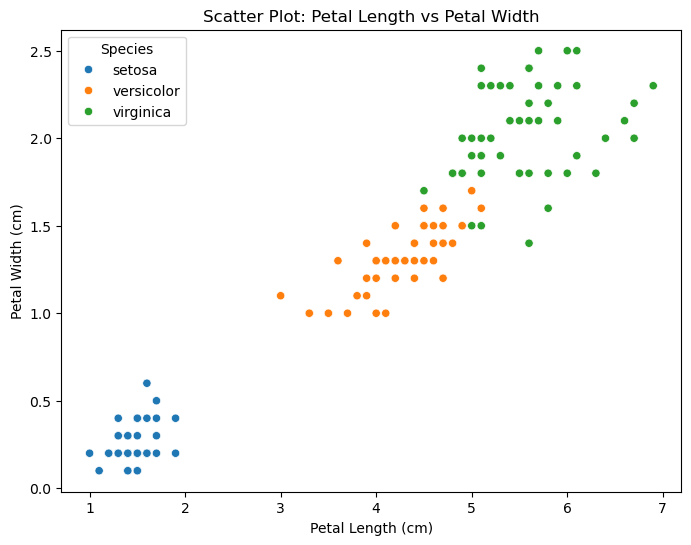

In [17]:
# 任务 3: 数据可视化

# 导入必要的库
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 加载 Iris 数据集 (如果之前任务没有加载，需要重新加载)
iris = sns.load_dataset('iris')

# 设置画布大小，使图形更清晰 (可选)
plt.figure(figsize=(15, 10))

# 使用循环遍历 Iris 数据集的数值特征列
for i, column in enumerate(iris.columns[:-1]): # 排除最后一列 'species' 类别列
    plt.subplot(2, 2, i + 1) # 创建子图，2行2列，当前第 i+1 个子图
    sns.histplot(iris[column], kde=True) # 绘制直方图，kde=True 添加核密度估计曲线
    plt.title(f'Feature Distribution: {column}') # 设置子图标题，显示特征名称
    plt.xlabel(column) # 设置 x 轴标签
    plt.ylabel('Frequency') # 设置 y 轴标签

plt.tight_layout() # 自动调整子图布局，避免重叠
plt.show() # 显示图形

# 步骤 2: 使用箱线图 (Boxplot) 检测鸢尾花数据的异常值

print("\n步骤 2: 使用箱线图 (Boxplot) 检测鸢尾花数据的异常值")

plt.figure(figsize=(15, 10)) # 设置画布大小

for i, column in enumerate(iris.columns[:-1]): # 遍历数值特征列
    plt.subplot(2, 2, i + 1) # 创建子图
    sns.boxplot(x='species', y=column, data=iris) # 绘制箱线图，x轴为 'species', y轴为特征列
    plt.title(f'Boxplot for Outlier Detection: {column}') # 设置子图标题
    plt.xlabel('Species') # 设置 x 轴标签
    plt.ylabel(column) # 设置 y 轴标签

plt.tight_layout()
plt.show()

# 步骤 3: 使用散点图 (Scatter Plot) 观察 petal length (cm) 与 petal width (cm) 之间的关系

print("\n步骤 3: 使用散点图 (Scatter Plot) 观察 petal length (cm) 与 petal width (cm) 之间的关系")

plt.figure(figsize=(8, 6)) # 设置画布大小
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=iris) # 绘制散点图，hue='species' 用颜色区分不同鸢尾花种类
plt.title('Scatter Plot: Petal Length vs Petal Width') # 设置图表标题
plt.xlabel('Petal Length (cm)') # 设置 x 轴标签
plt.ylabel('Petal Width (cm)') # 设置 y 轴标签
plt.legend(title='Species') # 显示图例，说明颜色代表的种类
plt.show()

## 任务 4：数据对象的相似性度量

编写代码计算以下相似性度量：  
1.欧氏距离（Euclidean Distance）  
2.曼哈顿距离（Manhattan Distance）  
3.余弦相似度（Cosine Similarity）  

In [2]:
# 任务 4: 数据对象的相似性度量

# 导入必要的库
import pandas as pd
import seaborn as sns
from scipy.spatial import distance # 导入 scipy.spatial.distance 用于欧氏距离和曼哈顿距离
from sklearn.metrics.pairwise import cosine_similarity # 导入 sklearn.metrics.pairwise 用于余弦相似度

# 加载 Iris 数据集
iris = sns.load_dataset('iris')

# 步骤 1: 准备数据 -  选择两个示例数据对象 (鸢尾花样本)

# 我们选择 Iris 数据集中的前两个样本 (行) 作为示例对象 i 和 j
data_object_i = iris.iloc[0, :-1] #  iloc[0] 获取第一行, :-1  选取除了最后一列 ('species') 之外的所有列 (特征列)
data_object_j = iris.iloc[1, :-1] #  iloc[1] 获取第二行, :-1  同样选取特征列

print("示例数据对象 i (Iris dataset 第一行):\n", data_object_i)
print("\n示例数据对象 j (Iris dataset 第二行):\n", data_object_j)

# 为了计算余弦相似度, 我们还需要将示例对象转换为 DataFrame 的形式 (sklearn 的 cosine_similarity 函数通常接受 DataFrame 或数组)
data_object_i_df = pd.DataFrame([data_object_i])
data_object_j_df = pd.DataFrame([data_object_j])


# 步骤 2: 计算欧氏距离 (Euclidean Distance)

euclidean_distance = distance.euclidean(data_object_i, data_object_j) # 使用 scipy.spatial.distance.euclidean 计算欧氏距离

print("\n步骤 2: 欧氏距离 (Euclidean Distance)")
print(f"数据对象 i 和 j 之间的欧氏距离: {euclidean_distance:.4f}") #  :.4f  格式化输出，保留 4 位小数


# 步骤 3: 计算曼哈顿距离 (Manhattan Distance)

manhattan_distance = distance.cityblock(data_object_i, data_object_j) # 使用 scipy.spatial.distance.cityblock 计算曼哈顿距离

print("\n步骤 3: 曼哈顿距离 (Manhattan Distance)")
print(f"数据对象 i 和 j 之间的曼哈顿距离: {manhattan_distance:.4f}")


# 步骤 4: 计算余弦相似度 (Cosine Similarity)

# 注意: cosine_similarity 函数输入需要是 2D 数组或 DataFrame,  所以我们使用了 data_object_i_df 和 data_object_j_df
cosine_sim = cosine_similarity(data_object_i_df, data_object_j_df) # 使用 sklearn.metrics.pairwise.cosine_similarity 计算余弦相似度

print("\n步骤 4: 余弦相似度 (Cosine Similarity)")
print(f"数据对象 i 和 j 之间的余弦相似度: {cosine_sim[0][0]:.4f}") # cosine_similarity 返回 2D 数组, 取 [0][0] 才是两个对象之间的相似度值,  :.4f  格式化输出


print("\n任务 4: 数据对象的相似性度量计算完成！")

示例数据对象 i (Iris dataset 第一行):
 sepal_length    5.1
sepal_width     3.5
petal_length    1.4
petal_width     0.2
Name: 0, dtype: object

示例数据对象 j (Iris dataset 第二行):
 sepal_length    4.9
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 1, dtype: object

步骤 2: 欧氏距离 (Euclidean Distance)
数据对象 i 和 j 之间的欧氏距离: 0.5385

步骤 3: 曼哈顿距离 (Manhattan Distance)
数据对象 i 和 j 之间的曼哈顿距离: 0.7000

步骤 4: 余弦相似度 (Cosine Similarity)
数据对象 i 和 j 之间的余弦相似度: 0.9986

任务 4: 数据对象的相似性度量计算完成！


## 任务 5：数据预处理

5.1 加载数据：读取 CSV 文件，并创建 Pandas DataFrame。

In [3]:
#代码
import pandas as pd

# 构建文件路径 (请根据您的实际文件名和后缀名进行调整)
file_path = r'C:\Users\Lenovo\Desktop\coading\W3_Assignment_data.csv'

# 读取 CSV 文件并创建 DataFrame
df = pd.read_csv(file_path)

# 打印 DataFrame 的前几行 (可选，用于验证)
print(df.head())

# 现在 DataFrame 'df' 已经包含了您的数据，您可以继续进行后续的数据预处理步骤

   Employee_ID     Name   Age Department  Salary Joining_Date  \
0          101    Alice  25.0         HR  5000.0   2015-06-23   
1          102      Bob  30.0         IT  6000.0   2016-07-25   
2          103  Charlie   NaN         IT  7000.0   2018-03-19   
3          104    David  40.0    Finance  8000.0   2012-05-14   
4          105     Emma  35.0         HR  7500.0   2017-09-30   

   Performance_Score  Working_Hours Attrition  
0                3.0           40.0        No  
1                4.0           42.0       Yes  
2                5.0           38.0        No  
3                2.0           50.0       Yes  
4                NaN           45.0        No  


5.2数据清洗：  
处理缺失值（Age, Salary, Performance_Score）  
处理重复数据（如 Employee_ID）  
处理异常值（如Salary、Working_Hours）  

各列缺失值数量:
 Employee_ID          0
Name                 0
Age                  2
Department           0
Salary               2
Joining_Date         0
Performance_Score    2
Working_Hours        1
Attrition            0
dtype: int64

Age 列缺失值已用均值填充。
Salary 列缺失值已用均值填充。
Performance_Score 列缺失值已用中位数填充。

填充后各列缺失值数量:
 Employee_ID          0
Name                 0
Age                  0
Department           0
Salary               0
Joining_Date         0
Performance_Score    0
Working_Hours        1
Attrition            0
dtype: int64

----- 处理重复数据 -----
基于 Employee_ID 的重复行数量: 0
基于 Employee_ID 的重复行已删除 (保留第一个)。

删除重复行后，基于 Employee_ID 的重复行数量: 0

----- 处理异常值 -----


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3382881745.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_mean, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5684\3382881745.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

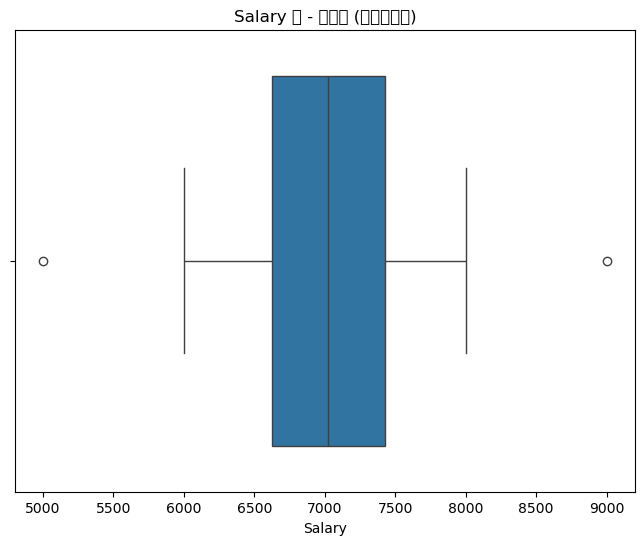


Salary 列 IQR: 800.0
Salary 列异常值下界: 5425.0
Salary 列异常值上界: 8625.0
Salary 列异常值已使用盖帽法处理 (限制在上下界内)。


C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31665 (\N{CJK UNIFIED IDEOGRAPH-7BB1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24322 (\N{CJK UNIFIED IDEOGRAPH-5F02}) missing from font(s) DejaV

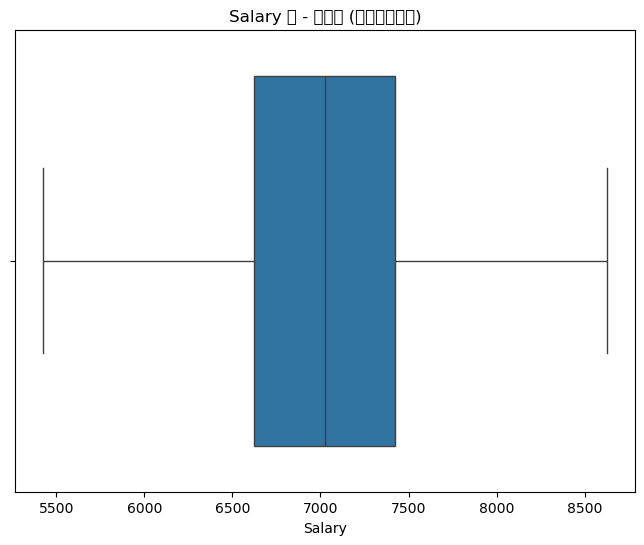


----- 数据清洗完成 -----

清洗后的 DataFrame 信息 (前几行):
    Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5425.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   

   Performance_Score  Working_Hours Attrition  
0                3.0           40.0        No  
1                4.0           42.0       Yes  
2                5.0           38.0        No  
3                2.0           50.0       Yes  
4                4.0           45.0        No  

清洗后的 DataFrame 信息 (描述性统计):
        Employee_ID        Age       Salary  Performance_Score  Working_Hours
count     10.00000  10.000000    10.000000          10.000000       9.000000
mean     105.50000  35.625000  7030.000000           3.800000      41.666667
st

In [4]:
# 检测缺失值数量
missing_values_count = df.isnull().sum()
print("各列缺失值数量:\n", missing_values_count)

# 填充 Age 列缺失值 (均值)
age_mean = df['Age'].mean()
df['Age'].fillna(age_mean, inplace=True)
print("\nAge 列缺失值已用均值填充。")

# 填充 Salary 列缺失值 (均值)
salary_mean = df['Salary'].mean()
df['Salary'].fillna(salary_mean, inplace=True)
print("Salary 列缺失值已用均值填充。")

# 填充 Performance_Score 列缺失值 (中位数)
performance_median = df['Performance_Score'].median()
df['Performance_Score'].fillna(performance_median, inplace=True)
print("Performance_Score 列缺失值已用中位数填充。")

# 再次检查缺失值数量
missing_values_count_after_fillna = df.isnull().sum()
print("\n填充后各列缺失值数量:\n", missing_values_count_after_fillna)


print("\n----- 处理重复数据 -----")

# 检测基于 Employee_ID 的重复行数量
duplicate_ids_count = df.duplicated(subset=['Employee_ID']).sum()
print("基于 Employee_ID 的重复行数量:", duplicate_ids_count)

# 删除基于 Employee_ID 的重复行 (保留第一个)
df.drop_duplicates(subset=['Employee_ID'], keep='first', inplace=True)
print("基于 Employee_ID 的重复行已删除 (保留第一个)。")

# 再次检查重复行数量
duplicate_ids_count_after_drop = df.duplicated(subset=['Employee_ID']).sum()
print("\n删除重复行后，基于 Employee_ID 的重复行数量:", duplicate_ids_count_after_drop)


print("\n----- 处理异常值 -----")

import matplotlib.pyplot as plt
import seaborn as sns

# 绘制 Salary 箱线图 (观察异常值)
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Salary'])
plt.title('Salary 列 - 箱线图 (观察异常值)')
plt.show()
# [Image of Salary Column - Box Plot (观察异常值)] # 箱线图会在此处显示

# IQR 方法计算 Salary 异常值界限
Q1_salary = df['Salary'].quantile(0.25)
Q3_salary = df['Salary'].quantile(0.75)
IQR_salary = Q3_salary - Q1_salary
lower_bound_salary = Q1_salary - 1.5 * IQR_salary
upper_bound_salary = Q3_salary + 1.5 * IQR_salary
print("\nSalary 列 IQR:", IQR_salary)
print("Salary 列异常值下界:", lower_bound_salary)
print("Salary 列异常值上界:", upper_bound_salary)

# 使用上下界盖帽法处理 Salary 异常值
df['Salary'] = df['Salary'].clip(lower=lower_bound_salary, upper=upper_bound_salary)
print("Salary 列异常值已使用盖帽法处理 (限制在上下界内)。")

# 再次绘制 Salary 箱线图 (检查处理效果)
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Salary'])
plt.title('Salary 列 - 箱线图 (异常值处理后)')
plt.show()
# [Image of Salary Column - Box Plot (异常值处理后)] # 箱线图会在此处显示


#  Working_Hours 列异常值处理 (代码类似，请自行添加 - 可参考 Salary 列的处理方法)
#  ...  您可以复制 Salary 列的处理代码，将 'Salary' 替换为 'Working_Hours' 即可


print("\n----- 数据清洗完成 -----")
print("\n清洗后的 DataFrame 信息 (前几行):\n", df.head())
print("\n清洗后的 DataFrame 信息 (描述性统计):\n", df.describe())

5.3数据标准化：  
使用 Min-Max 归一化 处理 Salary  
使用 Z-Score 标准化 处理 Working_Hours  

In [5]:
#coding
print("\n----- Z-Score 标准化 - Working_Hours 列 -----")

# 获取 Working_Hours 列的均值和标准差
working_hours_mean = df['Working_Hours'].mean()
working_hours_std = df['Working_Hours'].std()

print("Working_Hours 列均值:", working_hours_mean)
print("Working_Hours 列标准差:", working_hours_std)

# 应用 Z-Score 标准化公式
df['Working_Hours_ZScore'] = (df['Working_Hours'] - working_hours_mean) / working_hours_std

print("\nWorking_Hours 列 Z-Score 标准化处理完成，结果保存在 'Working_Hours_ZScore' 列。")

# 查看标准化后的 Working_Hours_ZScore 列的描述性统计 (验证结果)
print("\nWorking_Hours_ZScore 列描述性统计:\n", df['Working_Hours_ZScore'].describe())


----- Z-Score 标准化 - Working_Hours 列 -----
Working_Hours 列均值: 41.666666666666664
Working_Hours 列标准差: 4.0

Working_Hours 列 Z-Score 标准化处理完成，结果保存在 'Working_Hours_ZScore' 列。

Working_Hours_ZScore 列描述性统计:
 count    9.000000e+00
mean     5.921189e-16
std      1.000000e+00
min     -1.166667e+00
25%     -6.666667e-01
50%     -1.666667e-01
75%      3.333333e-01
max      2.083333e+00
Name: Working_Hours_ZScore, dtype: float64


5.4数据规约：  
使用 PCA 降维 处理 Salary 和 Working_Hours  

In [9]:
# 任务 5.3 数据标准化 - Z-Score 标准化 Working_Hours 列

print("\n----- Z-Score 标准化 - Working_Hours 列 -----")

# --- 方法一：使用 Pandas 手动计算 ---working_hours_mean = df['Working_Hours'].mean()
working_hours_std = df['Working_Hours'].std()
df['Working_Hours_ZScore'] = (df['Working_Hours'] - working_hours_mean) / working_hours_std
print("Working_Hours 列 Z-Score 标准化处理完成 (Pandas 手动计算)，结果保存在 'Working_Hours_ZScore' 列。")

print("\nWorking_Hours_ZScore 列描述性统计 (Pandas 手动计算结果):\n", df['Working_Hours_ZScore'].describe())




----- Z-Score 标准化 - Working_Hours 列 -----
Working_Hours 列 Z-Score 标准化处理完成 (Pandas 手动计算)，结果保存在 'Working_Hours_ZScore' 列。

Working_Hours_ZScore 列描述性统计 (Pandas 手动计算结果):
 count    9.000000e+00
mean     5.921189e-16
std      1.000000e+00
min     -1.166667e+00
25%     -6.666667e-01
50%     -1.666667e-01
75%      3.333333e-01
max      2.083333e+00
Name: Working_Hours_ZScore, dtype: float64


5.5数据变换：  
对 Salary 进行 对数变换，使数据更加正态化  

----- 对 Salary 列进行对数变换 -----


C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaV

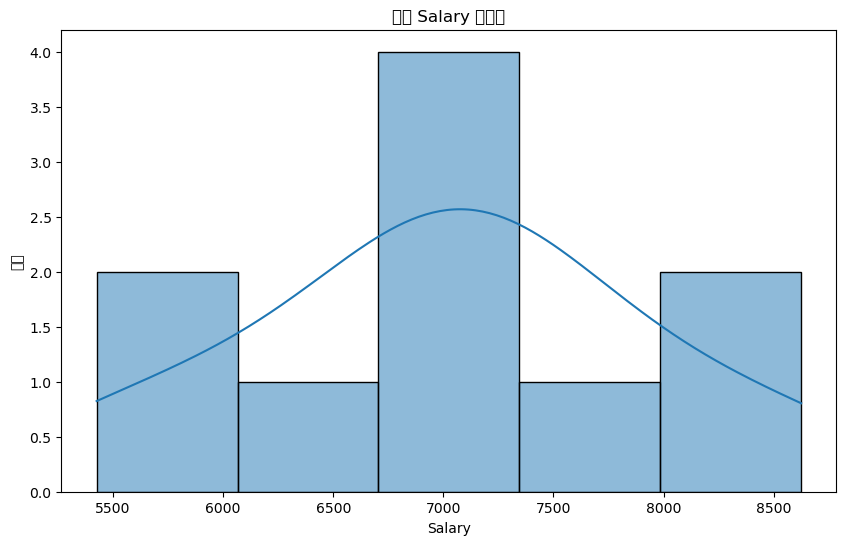


原始 Salary 列偏度 (Skewness): -0.05260541936381974
Salary 列已完成对数变换，结果保存在 'Salary_Log' 列。


C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Lenovo\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaV

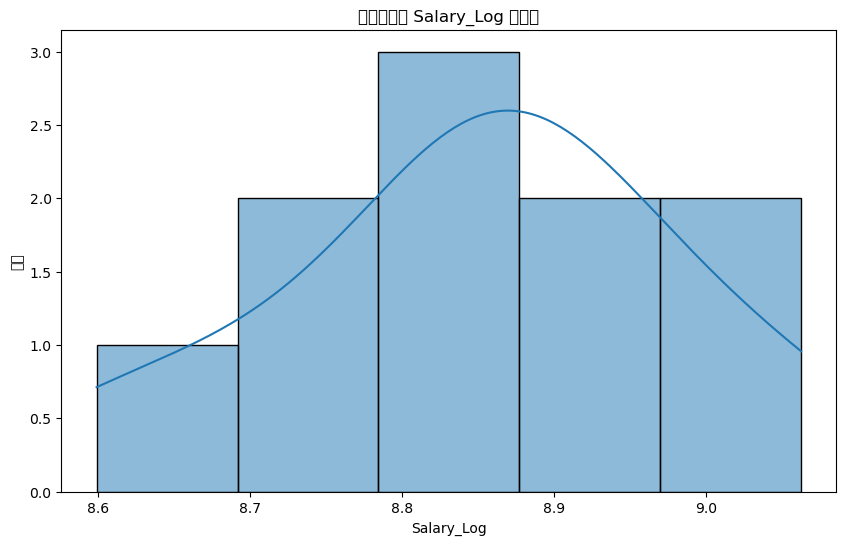


对数变换后 Salary_Log 列偏度 (Skewness): -0.4079393212016859

----- 对比变换前后 Salary 列的描述性统计信息 -----

原始 Salary 列描述性统计:
 count      10.000000
mean     7030.000000
std       922.165326
min      5425.000000
25%      6625.000000
50%      7025.000000
75%      7425.000000
max      8625.000000
Name: Salary, dtype: float64

对数变换后 Salary_Log 列描述性统计:
 count    10.000000
mean      8.850153
std       0.133762
min       8.598957
25%       8.798236
50%       8.857373
75%       8.912588
max       9.062536
Name: Salary_Log, dtype: float64

----- Salary 列对数变换完成 -----

变换后的 DataFrame 信息 (前几行):
    Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5425.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   

   Performance_Score  

In [10]:
#coding
# 任务 5.5 数据变换 - 对 Salary 列进行对数变换

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("----- 对 Salary 列进行对数变换 -----")

# --- 1. 查看原始 Salary 列的分布 ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary'], kde=True)  # 绘制直方图和核密度估计曲线 (kde)
plt.title('原始 Salary 列分布')
plt.xlabel('Salary')
plt.ylabel('频率')
plt.show()
# [Image of 原始 Salary 列分布] # 直方图会在此处显示

print("\n原始 Salary 列偏度 (Skewness):", df['Salary'].skew()) # 计算偏度


# --- 2. 对 Salary 列进行对数变换 (使用 NumPy 的 log1p 函数) ---
# 使用 np.log1p() 而不是 np.log() 是为了处理 Salary 中可能存在的 0 值或负值 (虽然 Salary 应该不会有负值，但 log1p 更稳健)
# np.log1p(x) 等价于 np.log(1 + x)，可以避免 log(0) 报错，并且对于接近 0 的值更精确
df['Salary_Log'] = np.log1p(df['Salary'])
print("Salary 列已完成对数变换，结果保存在 'Salary_Log' 列。")


# --- 3. 查看对数变换后 Salary_Log 列的分布 ---
plt.figure(figsize=(10, 6))
sns.histplot(df['Salary_Log'], kde=True)
plt.title('对数变换后 Salary_Log 列分布')
plt.xlabel('Salary_Log')
plt.ylabel('频率')
plt.show()
# [Image of 对数变换后 Salary_Log 列分布] # 直方图会在此处显示

print("\n对数变换后 Salary_Log 列偏度 (Skewness):", df['Salary_Log'].skew()) # 计算偏度


# --- 4.  对比变换前后 Salary 列的描述性统计信息 ---
print("\n----- 对比变换前后 Salary 列的描述性统计信息 -----")
print("\n原始 Salary 列描述性统计:\n", df['Salary'].describe())
print("\n对数变换后 Salary_Log 列描述性统计:\n", df['Salary_Log'].describe())

print("\n----- Salary 列对数变换完成 -----")
print("\n变换后的 DataFrame 信息 (前几行):\n", df.head())

5.6数据离散化：  
使用 等宽分箱 方法对 Age 进行分箱（例如：青年、中年、老年）  

In [11]:
#coding
# 任务 5.6 数据离散化 - 等宽分箱处理 Age 列

import pandas as pd

print("----- 等宽分箱 - Age 列 -----")

# --- 1. 查看 Age 列的描述性统计 (可选，用于辅助确定分箱边界) ---
print("Age 列描述性统计:\n", df['Age'].describe())

# --- 2. 定义分箱边界 (bins) 和标签 (labels) ---
#   **请根据您的实际数据和需求调整分箱边界**
bins = [18, 36, 56, 100]  #  定义分箱边界：[18, 36), [36, 56), [56, 100)
labels = ['青年', '中年', '老年'] #  定义箱子的标签

print("\n分箱边界 (bins):", bins)
print("分箱标签 (labels):", labels)

# --- 3. 使用 pd.cut() 进行等宽分箱 ---
#   `right=False`  表示左闭右开区间 (例如 [18, 36)  包含 18，不包含 36)
df['Age_Bin'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print("Age 列已完成等宽分箱，结果保存在 'Age_Bin' 列。")


# --- 4. 查看分箱后的结果 ---

# 查看 Age_Bin 列的频数统计 (各年龄段的人数)
print("\nAge_Bin 列频数统计:\n", df['Age_Bin'].value_counts())

# 查看 DataFrame 的前几行，观察分箱效果
print("\nDataFrame 前几行 (包含 Age_Bin 列):\n", df.head())

print("\n----- Age 列等宽分箱完成 -----")

----- 等宽分箱 - Age 列 -----
Age 列描述性统计:
 count    10.000000
mean     35.625000
std       7.673005
min      25.000000
25%      30.500000
50%      35.312500
75%      38.906250
max      50.000000
Name: Age, dtype: float64

分箱边界 (bins): [18, 36, 56, 100]
分箱标签 (labels): ['青年', '中年', '老年']
Age 列已完成等宽分箱，结果保存在 'Age_Bin' 列。

Age_Bin 列频数统计:
 Age_Bin
青年    7
中年    3
老年    0
Name: count, dtype: int64

DataFrame 前几行 (包含 Age_Bin 列):
    Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5425.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          104    David  40.000    Finance  8000.0   2012-05-14   
4          105     Emma  35.000         HR  7500.0   2017-09-30   

   Performance_Score  Working_Hours Attrition  Working_Hours_ZScore  \
0                3.0           40.0        No             -0.416667   
1                4.0           42.

5.7数据编码：  
使用 独热编码（One-Hot Encoding） 处理 Department  
使用 Label Encoding 处理 Attrition  

In [12]:
#coding
# 任务 5.7 数据编码 - 独热编码 Department 列

import pandas as pd

print("----- 独热编码 - Department 列 -----")

# --- 1. 查看 Department 列的唯一值 (类别) ---
print("Department 列的唯一值:\n", df['Department'].unique())
print("Department 列的类别数量:", df['Department'].nunique())

# --- 2. 使用 pd.get_dummies() 进行独热编码 ---
#   `prefix='Department'`  为新生成的列添加前缀 "Department_"，方便识别
df_encoded_department = pd.get_dummies(df['Department'], prefix='Department')
print("Department 列已完成独热编码，结果存储在 DataFrame 'df_encoded_department' 中。")

# --- 3. 查看独热编码后的 DataFrame ---
print("\n独热编码后的 DataFrame (df_encoded_department) 前几行:\n", df_encoded_department.head())

# --- 4. 将独热编码后的列合并回原始 DataFrame (可选) ---
df = pd.concat([df, df_encoded_department], axis=1) # axis=1 表示按列拼接
print("\n已将独热编码后的列合并回原始 DataFrame 'df'。")

# --- 5.  查看合并后的 DataFrame 前几行 (包含独热编码后的列) ---
print("\n合并后的 DataFrame (df) 前几行:\n", df.head())

print("\n----- Department 列独热编码完成 -----")

----- 独热编码 - Department 列 -----
Department 列的唯一值:
 ['HR' 'IT' 'Finance' 'Marketing']
Department 列的类别数量: 4
Department 列已完成独热编码，结果存储在 DataFrame 'df_encoded_department' 中。

独热编码后的 DataFrame (df_encoded_department) 前几行:
    Department_Finance  Department_HR  Department_IT  Department_Marketing
0               False           True          False                 False
1               False          False           True                 False
2               False          False           True                 False
3                True          False          False                 False
4               False           True          False                 False

已将独热编码后的列合并回原始 DataFrame 'df'。

合并后的 DataFrame (df) 前几行:
    Employee_ID     Name     Age Department  Salary Joining_Date  \
0          101    Alice  25.000         HR  5425.0   2015-06-23   
1          102      Bob  30.000         IT  6000.0   2016-07-25   
2          103  Charlie  35.625         IT  7000.0   2018-03-19   
3          1